In [2]:
import sys

sys.path.append("..")

from nilearn.image import mean_img
from mri_loader import MRI
import pandas as pd
from nilearn.decoding import Decoder
import nibabel as nib


In [4]:
import numpy as np
from nibabel.affines import apply_affine
from mri_loader import MRI

import nibabel as nib

from nilearn.maskers import NiftiMasker
import lib.mni_to_atlas as mni_to_atlas

mni_to_atlas._ATLASES_PATH = "../lib"

atlas = mni_to_atlas.AtlasBrowser("AAL3")

ROI = ['Precentral_L', 'Precentral_R', 'Supp_Motor_Area_L', 'Supp_Motor_Area_R']


sample = MRI(1, 1, folder='..').data
inv_affine = np.linalg.inv(sample.affine)

masks = {}
masks_image = {}
lookup_regions = {v: k for k, v in atlas._region_names.items()}

merged_mask = []

for region in ROI:
    index = lookup_regions[region]

    atlas_mask = np.argwhere(atlas._image == index)
    mni_mask = atlas._convert_atlas_to_mni_space(atlas_mask)
    image_mask = apply_affine(inv_affine, mni_mask)
    cleaned_mask = np.unique(np.round(image_mask), axis=0).astype(np.int32)
    merged_mask.append(cleaned_mask)

merged_mask = np.concatenate(merged_mask, axis=0)

applied_mask = np.zeros(sample.shape[:3], dtype=np.uint8)
applied_mask[merged_mask[:, 0], merged_mask[:, 1], merged_mask[:, 2]] = 1

img = nib.Nifti1Image(applied_mask, affine=sample.affine)
mask = NiftiMasker(mask_img=img)
mask.fit()



,"mask_img mask_img: Niimg-like object or None, default=NoneSee :ref:`extracting_data`.Mask for the data. If not given, a mask is computed in the fit step.Optional parameters (mask_args and mask_strategy) can be set tofine tune the mask extraction.If the mask and the images have different resolutions, the imagesare resampled to the mask resolution.If target_shape and/or target_affine are provided, the mask isresampled first. After this, the images are resampled to theresampled mask.",<nibabel.nift...x7f12ff4dc1a0>
,"runs runs: :obj:`numpy.ndarray` or None, default=NoneAdd a run level to the preprocessing. Each run will bedetrended independently. Must be a 1D array of n_samples elements.",None
,"smoothing_fwhm smoothing_fwhm: :obj:`float` or :obj:`int` or None, optional.If `smoothing_fwhm` is not `None`,it gives the :term:`full-width at half maximum` in millimetersof the spatial smoothing to apply to the signal.",None
,"standardize standardize: any of: 'zscore_sample', 'zscore', 'psc', True, False or None; default=FalseStrategy to standardize the signal:- ``'zscore_sample'``: The signal is z-scored. Timeseries are shifted to zero mean and scaled to unit variance. Uses sample std.- ``'zscore'``: The signal is z-scored. Timeseries are shifted to zero mean and scaled to unit variance. Uses population std by calling default :obj:`numpy.std` with N - ``ddof=0``. .. nilearn_deprecated:: 0.10.1 This option will be removed in Nilearn version 0.14.0. Use ``zscore_sample`` instead.- ``'psc'``: Timeseries are shifted to zero mean value and scaled to percent signal change (as compared to original mean signal).- ``True``: The signal is z-scored (same as option `zscore`). Timeseries are shifted to zero mean and scaled to unit variance. .. nilearn_deprecated:: 0.13.0 In nilearn version 0.15.0, ``True`` will be replaced by ``'zscore_sample'``.- ``False``: Do not standardize the data. .. nilearn_deprecated:: 0.13.0 In nilearn version 0.15.0, ``False`` will be replaced by ``None``... nilearn_deprecated:: 0.15.0dev The default will be changed to ``None`` in version 0.15.0.",False
,"standardize_confounds standardize_confounds: :obj:`bool`, default=TrueIf set to `True`, the confounds are z-scored:their mean is put to 0 and their variance to 1 in the time dimension.",True
,"detrend detrend: :obj:`bool`, optionalWhether to detrend signals or not.",False
,"high_variance_confounds high_variance_confounds: :obj:`bool`, default=FalseIf True, high variance confounds are computed on provided image with:func:`nilearn.image.high_variance_confounds` and default parametersand regressed out.",False
,"low_pass low_pass: :obj:`float` or :obj:`int` or None, default=NoneLow cutoff frequency in Hertz.If specified, signals above this frequency will be filtered out.If `None`, no low-pass filtering will be performed.",None
,"high_pass high_pass: :obj:`float` or :obj:`int` or None, default=NoneHigh cutoff frequency in Hertz.If specified, signals below this frequency will be filtered out.",None
,"t_r t_r: :obj:`float` or :obj:`int` or None, default=None:term:`Repetition time`, in seconds (sampling period).Set to `None` if not provided.",None
,"target_affine target_affine: 3x3 or a 4x4 array-like, or None, default=NoneIf specified, the image is resampled corresponding to this new affine... note:: This parameter is passed to :func:`nilearn.image.resample_img`.",None


In [7]:

X = []
y = []
groups = []

window_pre  = 2
window_post = 4

subject = 14

print(subject)

try:
    data_source = MRI(subject, 5, folder='..')

    data = data_source.data
    repetition_time = data_source._t_r
except Exception as e:
    print("Skipping subject ", subject, e)

fdata = data.get_fdata()

labels = pd.read_csv(f"../labels/motor/labels_{subject}.csv")

for response, time in zip(labels['response'], labels['response time']):

    time /= 1000

    center_tr = int(time / repetition_time)
    start_tr  = center_tr - window_pre
    end_tr    = center_tr + window_post + 1

    if start_tr < 0 or end_tr > fdata.shape[3]:
        continue

    window = fdata[..., start_tr:end_tr]

    nifti_win = nib.Nifti1Image(window, data.affine)

    X.append(nifti_win)
    y += [response] * window.shape[3]
    groups+= [subject] * window.shape[3]




14


In [11]:
from nilearn.image import concat_imgs

X = concat_imgs(X)

In [13]:
from sklearn.model_selection import KFold

from nilearn.decoding import SearchLight

cv = KFold(n_splits=4)

searchlight = SearchLight(
    data_source.brain_mask,
    process_mask_img=img,
    radius=5.6,
    n_jobs=10,
    verbose=1,
    cv=cv,
)
searchlight.fit(X, y)

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:  2.1min remaining:  8.4min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:  2.4min finished


,"mask_img mask_img: Niimg-like object or None,See :ref:`extracting_data`.Boolean image giving location of voxels containing usable signals.",<nibabel.nift...x7f12fd7deff0>
,"process_mask_img process_mask_img: Niimg-like object or None, default=NoneSee :ref:`extracting_data`.Boolean image giving voxels on which searchlight should becomputed.",<nibabel.nift...x7f12ff4dc1a0>
,"radius radius: :obj:`float`, default=2.radius of the searchlight ball, in millimeters.",5.6
,"estimator estimator: 'svr', 'svc', or an estimator object implementing 'fit'The object to use to fit the data",'svc'
,"n_jobs n_jobs: :obj:`int`, default=1The number of CPUs to use to do the computation.`-1` means 'all CPUs'.",10
,"scoring scoring: :obj:`str` or callable or None, default=NoneThe scoring strategy to use. See the scikit-learn documentationIf callable, takes as arguments the fitted estimator, thetest data (X_test) and the test target (y_test) if y isnot None.",None
,"cv cv: cross-validation generator, :obj:`int` or None, default=NoneA cross-validation generator.See: https://scikit-learn.org/stable/modules/cross_validation.html.If None is passed, cv=3 will be used.It can be an integer, in which case it is the number of folds in aKFold using :class:`~sklearn.model_selection.StratifiedKFold`when groups is None in the ``fit`` method for this class.If groups is specified but ``cv``is not set to custom CV splitter, default is:class:`~sklearn.model_selection.LeaveOneGroupOut`.",KFold(n_split...shuffle=False)
,"verbose verbose: :obj:`bool` or :obj:`int`, default=0Verbosity level (``0`` or ``False`` means no message).",1


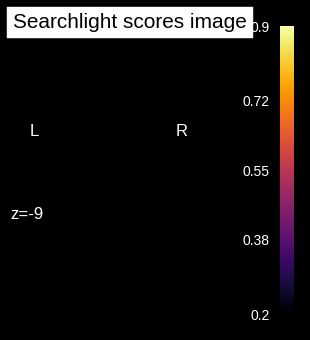

In [15]:
from nilearn.plotting import plot_img, plot_stat_map, show

plot_img(
    searchlight.scores_img_,
#    bg_img=mean_img(X),
    title="Searchlight scores image",
    display_mode="z",
    cut_coords=[-9],
    vmin=0.2,
    vmax=0.9,
    cmap="inferno",
    threshold=0.2,
    black_bg=True,
    colorbar=True,
)

/home/calculateur2/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



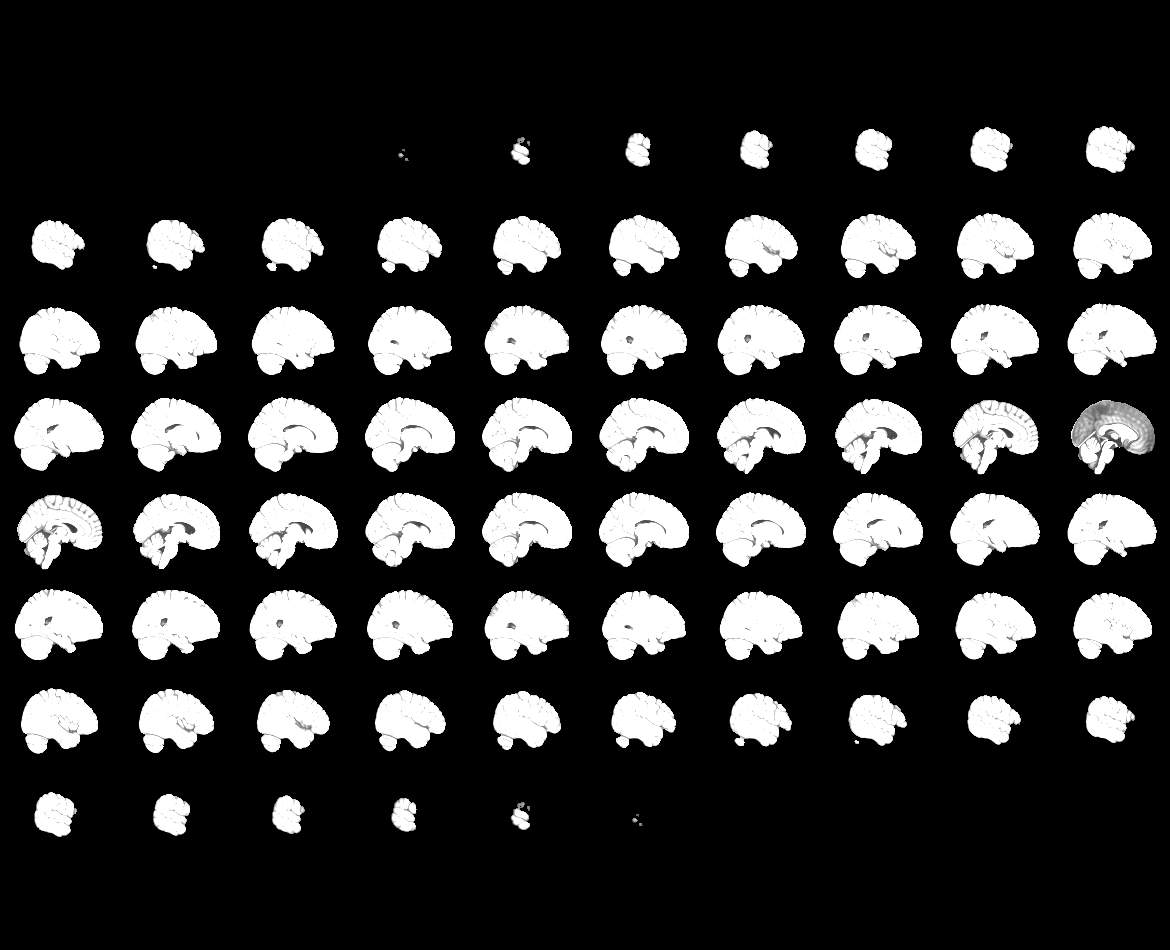
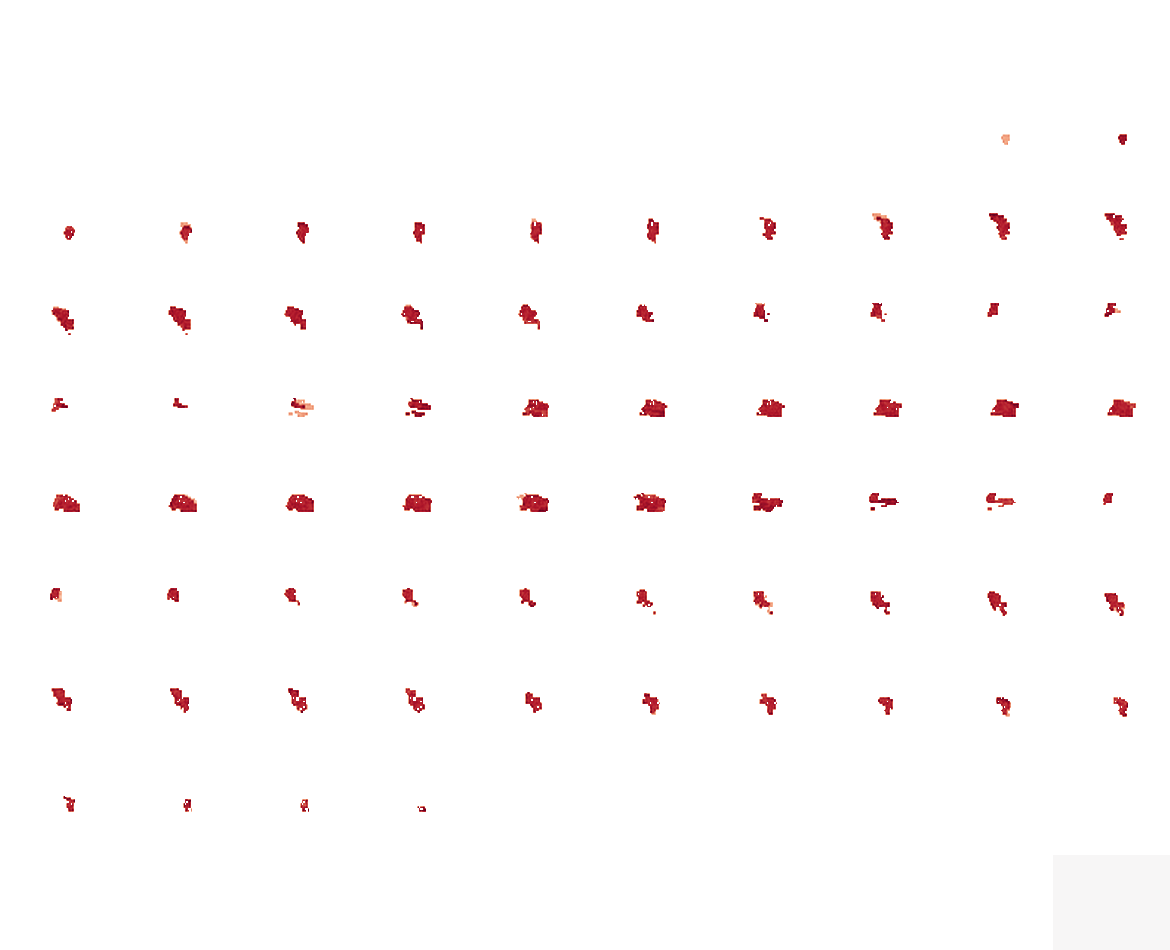

[BatchedCalls.__call__] Job #9, processed 0/390 steps (0.00%, 3777.1 seconds remaining)

[BatchedCalls.__call__] Job #9, processed 10/390 steps (2.56%, 129.7 seconds remaining)

[BatchedCalls.__call__] Job #9, processed 20/390 steps (5.13%, 110.4 seconds remaining)

[BatchedCalls.__call__] Job #9, processed 30/390 steps (7.69%, 103.3 seconds remaining)

[BatchedCalls.__call__] Job #9, processed 40/390 steps (10.26%, 100.0 seconds remaining)

[BatchedCalls.__call__] Job #9, processed 50/390 steps (12.82%, 96.7 seconds remaining)

[BatchedCalls.__call__] Job #9, processed 60/390 steps (15.38%, 94.8 seconds remaining)

[BatchedCalls.__call__] Job #9, processed 70/390 steps (17.95%, 93.7 seconds remaining)

[BatchedCalls.__call__] Job #9, processed 80/390 steps (20.51%, 89.8 seconds remaining)

[BatchedCalls.__call__] Job #9, processed 90/390 steps (23.08%, 86.0 seconds remaining)

[BatchedCalls.__call__] Job #9, processed 100/390 steps (25.64%, 82.4 seconds remaining)

[BatchedCalls.__cal

In [18]:
from nilearn.plotting import view_img

view_img(searchlight.scores_img_, title="Searchlight weights", threshold=0.4, dim=-1)

[NiftiMasker.wrapped] Loading mask from <nibabel.nifti1.Nifti1Image object at 0x7f12ff4dc1a0>
[NiftiMasker.wrapped] Loading data from <nibabel.nifti1.Nifti1Image object at 0x7f12ff5c6bd0>
[NiftiMasker.wrapped] Resampling mask
[NiftiMasker.wrapped] Finished fit


/tmp/ipykernel_15714/601727820.py:11: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  fmri_masked = nifti_masker.fit_transform(X)


[NiftiMasker.wrapped] Loading data from <nibabel.nifti1.Nifti1Image object at 0x7f12ff5c6bd0>
[NiftiMasker.wrapped] Extracting region signals
[NiftiMasker.wrapped] Cleaning extracted signals
[NiftiMasker.inverse_transform] Computing image from signals


/home/calculateur2/miniconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [3881 3889] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/calculateur2/miniconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/tmp/ipykernel_15714/601727820.py:22: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plot_stat_map(


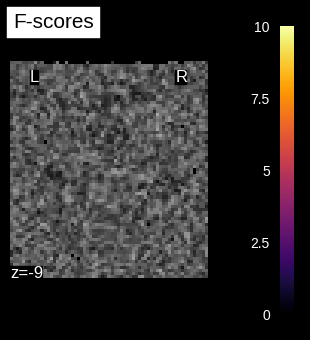

In [22]:
from sklearn.feature_selection import f_classif
from nilearn.image import get_data, new_img_like

from nilearn.maskers import NiftiMasker

# For decoding, standardizing is often very important
nifti_masker = NiftiMasker(
    mask_img=img,
    verbose=1,
)
fmri_masked = nifti_masker.fit_transform(X)

_, p_values = f_classif(fmri_masked, y)
p_values = -np.log10(p_values)
p_values[p_values > 10] = 10
p_unmasked = get_data(nifti_masker.inverse_transform(p_values))

mean_fmri = mean_img(X)
# F_score results
p_ma = np.ma.array(p_unmasked, mask=np.logical_not(img))
f_score_img = new_img_like(mean_fmri, p_ma)
plot_stat_map(
    f_score_img,
    mean_fmri,
    title="F-scores",
    display_mode="z",
    cut_coords=[-9],
    cmap="inferno",
)


/tmp/ipykernel_15714/786039819.py:1: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  view_img(
/home/calculateur2/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



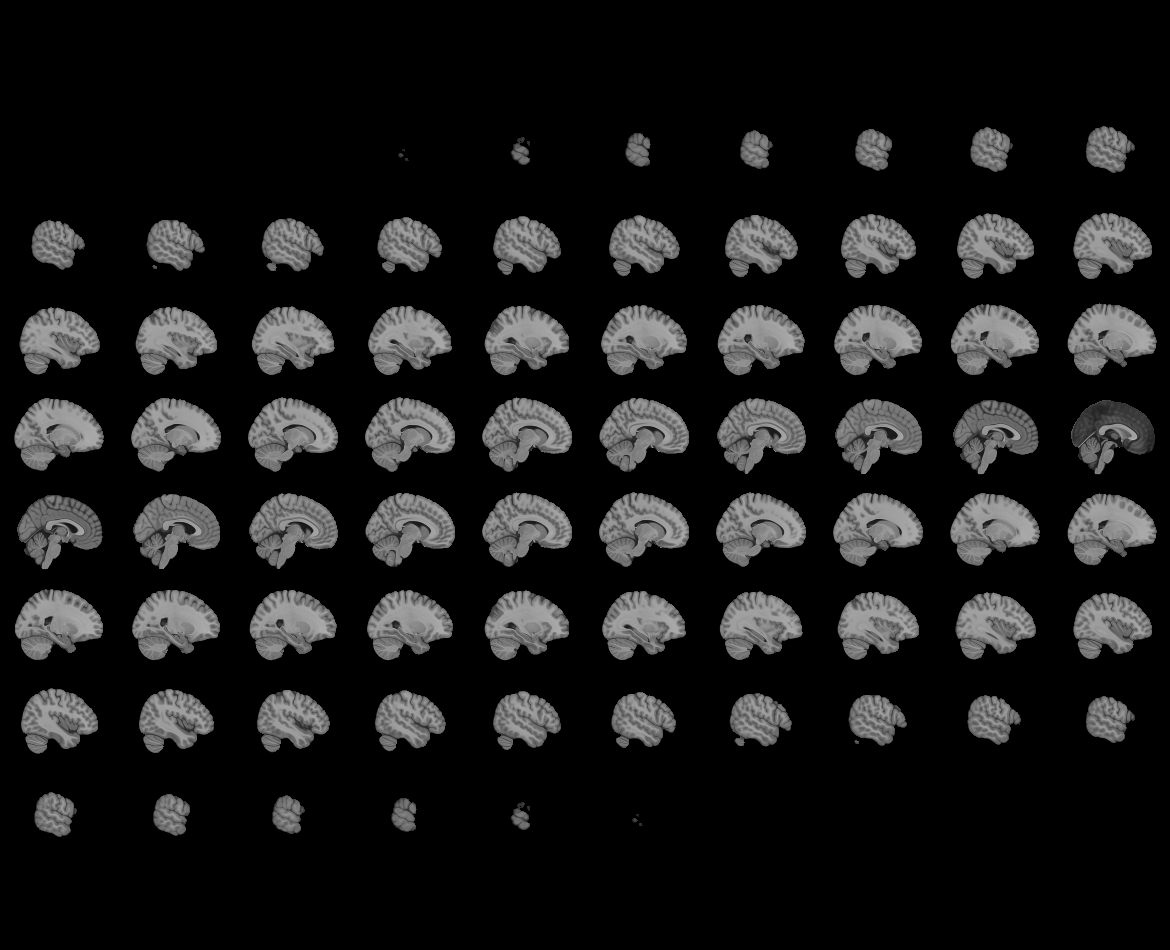
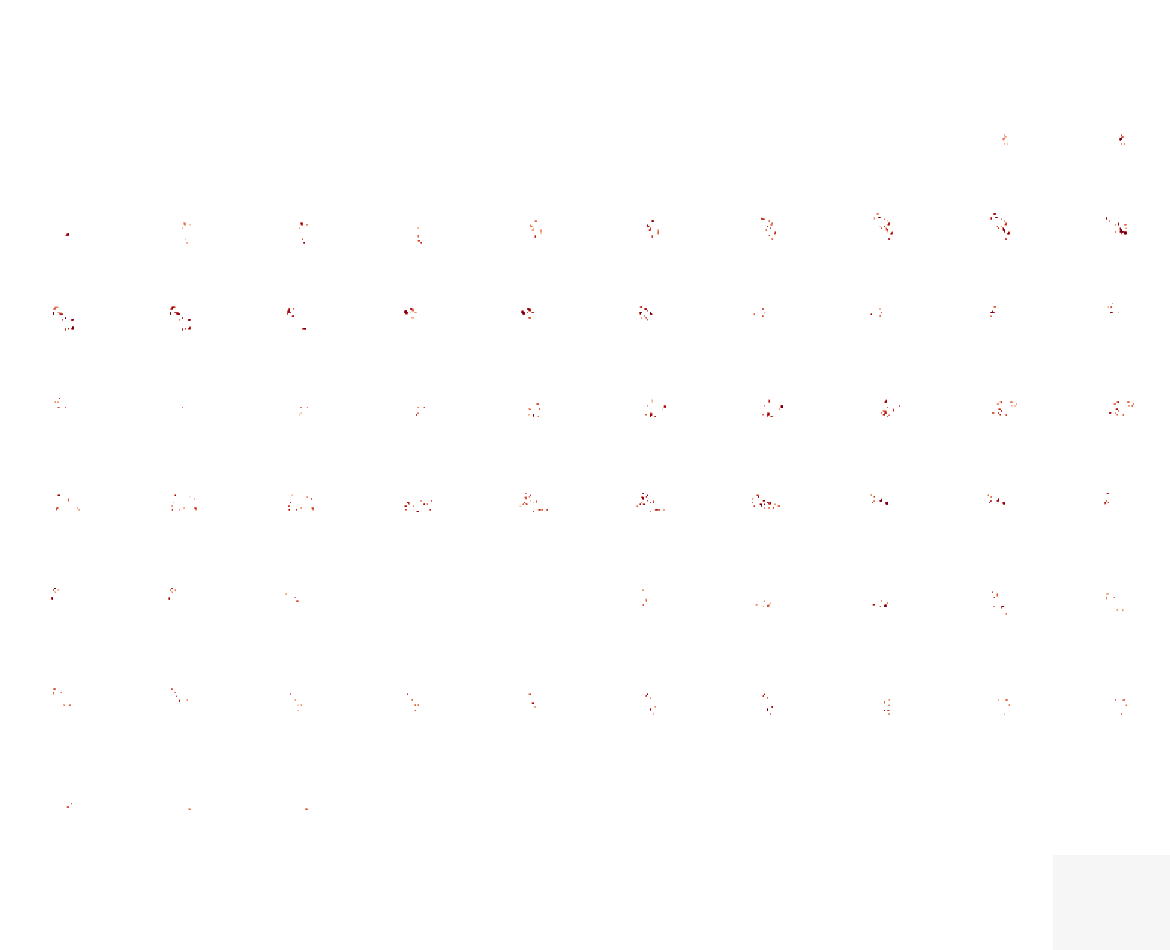

In [24]:
view_img(
    f_score_img, threshold=5.0
)
